In [1]:
import numpy as np
from scipy.linalg import expm
import scipy.linalg as la
import matplotlib.pyplot as plt

In [2]:
# setting parameters and defining the Hamiltonian                              
            
def hamiltonian(w_0, w_1, w, t):                                             # time steps
    H = np.zeros((len(t), 2, 2), dtype=complex)                              # Hamiltonian initialization
    H[:, 0, 0] = w_0
    H[:, 1, 1] = -w_0
    H[:, 0, 1] = w_1 * np.exp(-1j * w * t)
    H[:, 1, 0] = w_1 * np.exp(1j * w * t)
    return H

In [10]:
# setting up a test state
t_array = np.arange(1,10,0.01)  
H_res = hamiltonian(1,1,2,t_array)
H_hdamp = hamiltonian(5,5,10,t_array)
H_ldamp = hamiltonian(0.4,0.4,0.8,t_array)
H_off = hamiltonian(1,1,4,t_array)

psi_test = np.array([1,0])
psi1_test = np.array([0,1])

In [11]:
# calculating time evolved state

def psi_t(H, psi_0, t):
    psi = psi_0.astype(complex)
    dt = t[1] - t[0]
    psi_t = []
    for i in range(len(t)):
        psi_t.append(psi)
        U = expm(-1j * H[i] * dt)
        psi = U @ psi
    return psi_t


In [12]:
psi_t_res = psi_t(H_res, psi_test,t_array)
psi_t_hdamp = psi_t(H_hdamp, psi_test,t_array)
psi_t_ldamp = psi_t(H_ldamp, psi_test,t_array)
psi_t_off = psi_t(H_off, psi_test,t_array)

In [13]:
def prob_t(H, psi1,psi2, t):
    probs = []
    psi1 = psi1.copy()
    dt = t[1] - t[0]
    for i in range(len(t)):
        amp = np.vdot(psi2, psi1[i])        # <1|psi(t)>
        probs.append(np.abs(amp)**2)
    return probs

In [14]:
np.shape(psi_t_res)

(900, 2)

In [15]:
prob_t_res = prob_t(H_res, psi_t_res, psi1_test, t_array)
prob_t_hdamp = prob_t(H_hdamp, psi_t_hdamp, psi1_test,t_array)
prob_t_ldamp = prob_t(H_ldamp, psi_t_ldamp, psi1_test,t_array)
prob_t_off = prob_t(H_off, psi_t_off, psi1_test,t_array)


<>:8: SyntaxWarning: invalid escape sequence '\p'
<>:8: SyntaxWarning: invalid escape sequence '\p'
/var/folders/4t/t515wkn52_9_fj_wtsmnsf2w0000gn/T/ipykernel_38001/3043280547.py:8: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel('$<1|\psi(t)>$')


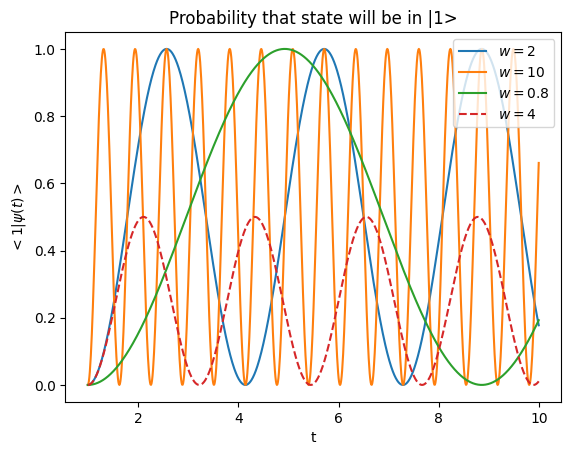

In [18]:
plt.plot(t_array, prob_t_res, label = '$w = 2$')
plt.plot(t_array, prob_t_hdamp, label = '$w = 10$')
plt.plot(t_array, prob_t_ldamp, label = '$w = 0.8$')
plt.plot(t_array, prob_t_off, label = '$w = 4$', ls = '--')

plt.title('Probability that state will be in |1>')
plt.xlabel('t')
plt.ylabel('$<1|\psi(t)>$')
plt.legend(loc = 'upper right')
plt.show()

So far I have looked at an idealized system where there is no noise or coupling to the environment so these oscillations would continue forever, however this is not realistic. There are two types of noise that I would like to look at: 

1. Spontaneous Emission (Relaxation $T_1$)
2. Pure Dephasing ($T_2$)


To do this I will need to move away from the State Vector picture and use the Density Matrix to calculate the evolution of the system.

In [20]:
! pip install qutip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 16.8 MB/s eta 0:00:00 0:00:01


In [21]:
from qutip import Bloch, about, basis, mesolve, sigmam, sigmax, sigmay, sigmaz